## Analisis y procesamiento de señales
# Trabajo Practico N^5
### Bernardita Aragon

En este trabajo se analizaron diferentes señales con el objetivo de estimar su densidad espectral de potencia (PSD) y determinar su ancho de banda.

Se trabajó con señales de ECG, PPG y tres señales de audio. Para la estimación de la PSD se utilizó el método de Welch, analizando diferentes longitudes de segmento para observar su efecto sobre la estimación espectral.

#### 1. Electrocardiograma (ECG)
Se comenzó analizando la señal de ECG en el dominio temporal. La señal utilizada corresponde al registro sin ruido y posee una frecuencia de muestreo de 1000 Hz.

ECG


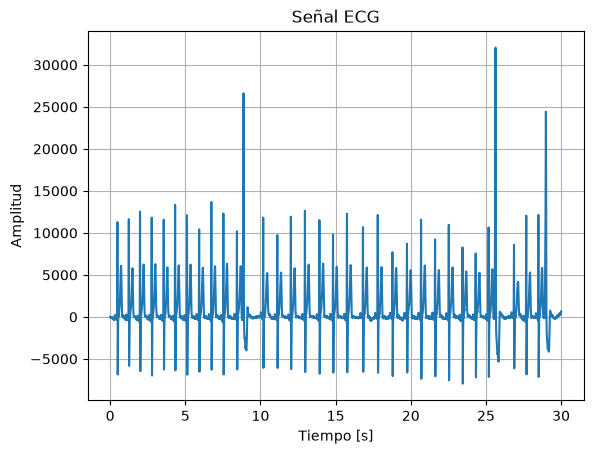

In [1]:
import numpy as np
from scipy import signal as sig
from scipy.signal import windows
import matplotlib.pyplot as plt
import scipy.io as sio

print("ECG")
fs_ecg = 1000 # Hz 1000 muestras por segundo

ecg_one_lead = np.load('ecg_sin_ruido.npy') #las muestras de mi senal

# GRAFICO DE LA SEÑAL ORIGINAL
N = len(ecg_one_lead)
T = N / fs_ecg
tt_ecg = np.arange(N) / fs_ecg

plt.figure()
plt.plot(tt_ecg, ecg_one_lead)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal ECG')
plt.grid()
plt.show()

Para estimar la densidad espectral de potencia (PSD) de la señal ECG se utilizó el método de Welch. Este método divide la señal en segmentos, calcula un periodograma para cada uno y luego los promedia.

La longitud de cada segmento se definió como:

$$
L=\frac{N}{K}
$$

donde $N$ es la cantidad total de muestras de la señal y $K$ es el parámetro utilizado para modificar la longitud de los segmentos.

La elección de $K$ implica un compromiso entre resolución espectral y estabilidad de la estimación. Para valores chicos de $K$, los segmentos son más largos, por lo que se obtiene una mejor resolución en frecuencia, aunque por lo tanto vamos a tener menos segmentos para promediar. En cambio, al aumentar $K$, los segmentos son más cortos y pueden realizarse más promedios, obteniendo una PSD más suavizada y estable, pero con menor resolución espectral.

Por este motivo se probaron tres valores de $K$: 15, 30 y 60, con el objetivo de observar cómo cambia la estimación de la PSD y determinar un K adecuado para la señal.

Los segmentos se superpusieron un 50 %, utilizando:

$$
noverlap=\frac{L}{2}
$$

De esta forma se aumenta la cantidad de segmentos disponibles para el promedio sin reducir aún más su longitud.

En cada segmento se aplicó una ventana Flat Top, lo que nos ayuda a reducir los efectos producidos por el truncamiento de los segmentos y obtener una representación adecuada de sus componentes espectrales. Además, se utilizó un número de puntos de FFT igual a la longitud total de la señal ($nfft=N$), obteniendo una grilla de frecuencias más densa para representar el espectro.

Finalmente, la PSD se normalizó respecto de su valor máximo y se expresó en dB para facilitar la comparación entre las estimaciones obtenidas con los distintos valores de $K$.

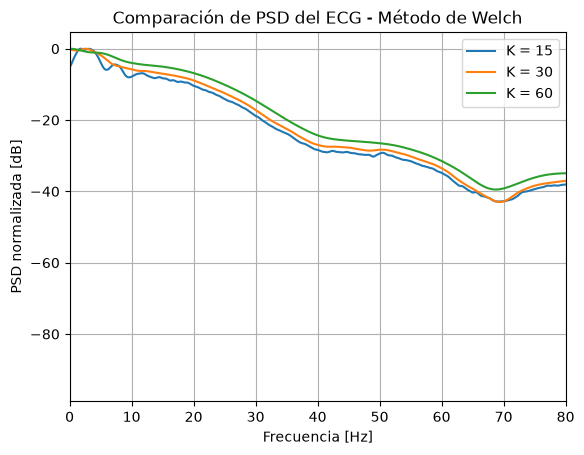

In [3]:
### K=30 ###
K=30
L=N//K
ventana= windows.flattop (L)

f_30, PSD_welch_30= sig.welch (ecg_one_lead, fs= fs_ecg, window= ventana, nperseg =L, noverlap= L//2, nfft=N)

PSD_welch_max_30 = np.max(PSD_welch_30)
PSD_welch_norm_30 = PSD_welch_30 / PSD_welch_max_30
PSD_db_30 = 10 * np.log10(np.abs(PSD_welch_norm_30))


### K=60 ###
K=60
L=N//K
ventana= windows.flattop (L)
f_60, PSD_welch_60= sig.welch (ecg_one_lead, fs= fs_ecg, window= ventana, nperseg =L, noverlap= L//2, nfft=N)

PSD_welch_max_60 = np.max(PSD_welch_60)
PSD_welch_norm_60 = PSD_welch_60 / PSD_welch_max_60
PSD_db_60 = 10 * np.log10(np.abs(PSD_welch_norm_60))


#PRUEBO CON K=15
K=15
L=N//K
ventana= windows.flattop (L)
f_15, PSD_welch_15= sig.welch (ecg_one_lead, fs= fs_ecg, window= ventana, nperseg =L, noverlap= L//2, nfft=N)

PSD_welch_max_15 = np.max(PSD_welch_15)
PSD_welch_norm_15 = PSD_welch_15 / PSD_welch_max_15
PSD_db_15 = 10 * np.log10(np.abs(PSD_welch_norm_15))


#GRAFICO
plt.figure()

plt.plot(f_15, PSD_db_15, label='K = 15')
plt.plot(f_30, PSD_db_30, label='K = 30')
plt.plot(f_60, PSD_db_60, label='K = 60')

plt.xlim(0, 80)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.title('Comparación de PSD del ECG - Método de Welch')
plt.grid()
plt.legend()
plt.show()

En la comparación de las PSD se observa que las tres estimaciones presentan un comportamiento general similar, aunque cambia el suavizado según el valor de $K$.

Para $K=15$, al utilizar segmentos más largos, se conservan con mayor detalle las variaciones del espectro. En cambio, para $K=60$ los segmentos son más cortos y la estimación resulta más suavizada, aunque con menor resolución espectral. El caso $K=30$ presenta un comportamiento intermedio entre ambos.

Para complementar la comparación, se estimó el ancho de banda correspondiente a cada valor de $K$.

K = 30 - Índice donde se alcanza el 99%: 919
K = 30 - Ancho de banda: 30.633333333333333 Hz
K = 60 - Índice donde se alcanza el 99%: 981
K = 60 - Ancho de banda: 32.7 Hz
K = 15 - Índice donde se alcanza el 99%: 901
K = 15 - Ancho de banda: 30.03333333333333 Hz


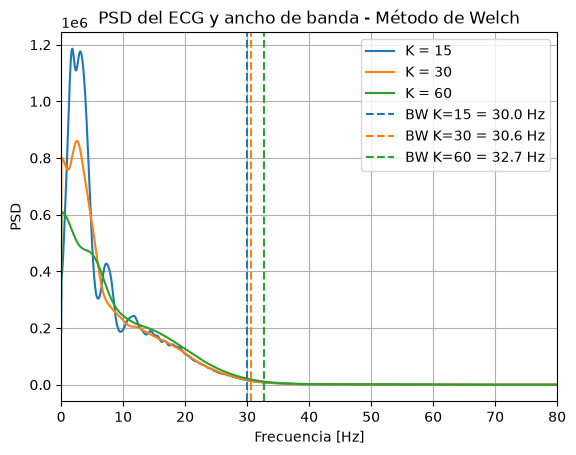

In [7]:
### K=30 ###
energia_acum = np.cumsum(PSD_welch_30)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw = i
        break

bw_ecg_30 = f_30[indice_bw]

print("K = 30 - Índice donde se alcanza el 99%:", indice_bw)
print("K = 30 - Ancho de banda:", bw_ecg_30, "Hz")

### K=60 ###
energia_acum = np.cumsum(PSD_welch_60)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw = i
        break

bw_ecg_60 = f_60[indice_bw]

print("K = 60 - Índice donde se alcanza el 99%:", indice_bw)
print("K = 60 - Ancho de banda:", bw_ecg_60, "Hz")

### K=15 ###
energia_acum = np.cumsum(PSD_welch_15)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw = i
        break

bw_ecg_15 = f_15[indice_bw]

print("K = 15 - Índice donde se alcanza el 99%:", indice_bw)
print("K = 15 - Ancho de banda:", bw_ecg_15, "Hz")

#GRAFICO

plt.figure()

# PSD 
plt.plot(f_15, PSD_welch_15, color='tab:blue', label='K = 15')
plt.plot(f_30, PSD_welch_30, color='tab:orange', label='K = 30')
plt.plot(f_60, PSD_welch_60, color='tab:green', label='K = 60')

# BW
plt.axvline(bw_ecg_15, color='tab:blue', linestyle='--',
            label=f'BW K=15 = {bw_ecg_15:.1f} Hz')

plt.axvline(bw_ecg_30, color='tab:orange', linestyle='--',
            label=f'BW K=30 = {bw_ecg_30:.1f} Hz')

plt.axvline(bw_ecg_60, color='tab:green', linestyle='--',
            label=f'BW K=60 = {bw_ecg_60:.1f} Hz')

plt.xlim(0, 80)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del ECG y ancho de banda - Método de Welch')
plt.grid()
plt.legend()
plt.show()

Los tres valores de ancho de banda obtenidos son cercanos entre sí, por lo que la estimación del ancho de banda resulta relativamente estable frente a los cambios en la segmentación.

Me voy a quedar con  $K=30$ ya que permite mantener los principales detalles del espectro sin presentar una variabilidad excesiva.

Por lo tanto, se adopta como ancho de banda representativo de la señal ECG:

$$
BW_{ECG} \approx 30,6 \text{ Hz}
$$

#### 2. Pletismografía (PPG)
A continuación se analizó la señal de pletismografía (PPG) sin ruido, muestreada a una frecuencia de 400 Hz. En primer lugar se observó la señal en el dominio temporal y luego se estimó su PSD mediante el método de Welch.

PPG


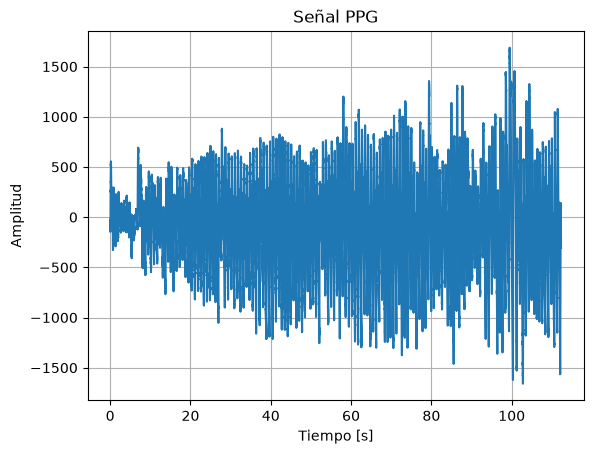

In [8]:
print("PPG")
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')

# GRAFICO DE LA SEÑAL ORIGINAL
N_ppg = len(ppg)
T_ppg = N_ppg / fs_ppg
tt_ppg = np.arange(N_ppg) / fs_ppg

plt.figure()
plt.plot(tt_ppg, ppg)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Señal PPG')
plt.grid()
plt.show()

Para estimar la PSD de la señal PPG se utilizó nuevamente el método de Welch, manteniendo el mismo criterio que para el ECG.

Se probaron los valores $K=15$, $K=30$ y $K=60$, modificando así la longitud de los segmentos.

El objetivo fue comparar nuevamente el compromiso entre resolución espectral y estabilidad de la estimación, y analizar cómo afecta al ancho de banda obtenido.

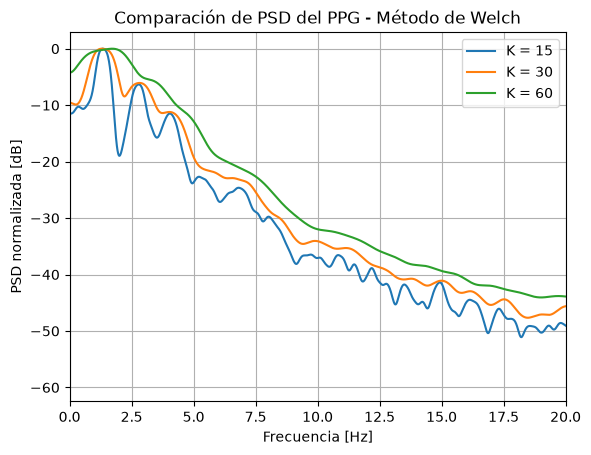

In [9]:
### K=30 ###
K_ppg=30
L_ppg=N_ppg//K_ppg
ventana= windows.flattop (L_ppg)

f_30_ppg, PSD_welch_30_ppg= sig.welch (ppg, fs= fs_ppg, window= ventana, nperseg =L_ppg, noverlap= L_ppg//2, nfft=N_ppg)

PSD_welch_max_30_ppg = np.max(PSD_welch_30_ppg)
PSD_welch_norm_30_ppg = PSD_welch_30_ppg / PSD_welch_max_30_ppg
PSD_db_30_ppg = 10 * np.log10(np.abs(PSD_welch_norm_30_ppg))

### K=60 ###
K_ppg=60
L_ppg=N_ppg//K_ppg
ventana= windows.flattop (L_ppg)

f_60_ppg, PSD_welch_60_ppg= sig.welch (ppg, fs= fs_ppg, window= ventana, nperseg =L_ppg, noverlap= L_ppg//2, nfft=N_ppg)

PSD_welch_max_60_ppg = np.max(PSD_welch_60_ppg)
PSD_welch_norm_60_ppg = PSD_welch_60_ppg / PSD_welch_max_60_ppg
PSD_db_60_ppg = 10 * np.log10(np.abs(PSD_welch_norm_60_ppg))

### K=15 ###
K_ppg=15
L_ppg=N_ppg//K_ppg
ventana= windows.flattop (L_ppg)

f_15_ppg, PSD_welch_15_ppg= sig.welch (ppg, fs= fs_ppg, window= ventana, nperseg =L_ppg, noverlap= L_ppg//2, nfft=N_ppg)

PSD_welch_max_15_ppg = np.max(PSD_welch_15_ppg)
PSD_welch_norm_15_ppg = PSD_welch_15_ppg / PSD_welch_max_15_ppg
PSD_db_15_ppg = 10 * np.log10(np.abs(PSD_welch_norm_15_ppg))


# GRAFICO
plt.figure()

plt.plot(f_15_ppg, PSD_db_15_ppg, color='tab:blue', label='K = 15')
plt.plot(f_30_ppg, PSD_db_30_ppg, color='tab:orange', label='K = 30')
plt.plot(f_60_ppg, PSD_db_60_ppg, color='tab:green', label='K = 60')

plt.xlim(0, 20)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.title('Comparación de PSD del PPG - Método de Welch')
plt.grid()
plt.legend()
plt.show()

En la comparación de las PSD del PPG se observa nuevamente el efecto de la longitud de los segmentos sobre la estimación espectral.

Para $K=15$, al utilizar segmentos más largos, se observan con mayor detalle las variaciones del espectro. En cambio, para $K=60$ la estimación resulta más suavizada debido al uso de segmentos más cortos, aunque con una menor resolución en frecuencia.

El caso $K=30$ presenta un comportamiento intermedio entre ambos. Para complementar la comparación, se estimó el ancho de banda correspondiente a cada valor de $K$.

K = 30 - Índice donde se alcanza el 99%: 618
K = 30 - Ancho de banda: 5.503239163828224 Hz
K = 60 - Índice donde se alcanza el 99%: 640
K = 60 - Ancho de banda: 5.699147354126316 Hz
K = 15 - Índice donde se alcanza el 99%: 605
K = 15 - Ancho de banda: 5.3874752331975335 Hz


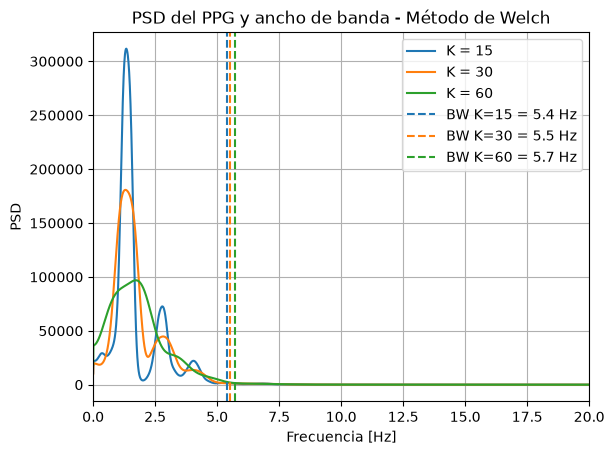

In [10]:
### K=30 ###
energia_acum = np.cumsum(PSD_welch_30_ppg)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw_ppg = i
        break

bw_ppg_30 = f_30_ppg[indice_bw_ppg]

print("K = 30 - Índice donde se alcanza el 99%:", indice_bw_ppg)
print("K = 30 - Ancho de banda:", bw_ppg_30, "Hz")

### K=60 ###
energia_acum = np.cumsum(PSD_welch_60_ppg)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw_ppg = i
        break

bw_ppg_60 = f_60_ppg[indice_bw_ppg]

print("K = 60 - Índice donde se alcanza el 99%:", indice_bw_ppg)
print("K = 60 - Ancho de banda:", bw_ppg_60, "Hz")

### K=15 ###
energia_acum = np.cumsum(PSD_welch_15_ppg)
energia_acum = energia_acum / energia_acum[-1]

for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.99:
        indice_bw_ppg = i
        break

bw_ppg_15 = f_15_ppg[indice_bw_ppg]

print("K = 15 - Índice donde se alcanza el 99%:", indice_bw_ppg)
print("K = 15 - Ancho de banda:", bw_ppg_15, "Hz")


# GRAFICO 
plt.figure()

plt.plot(f_15_ppg, PSD_welch_15_ppg, color='tab:blue', label='K = 15')
plt.plot(f_30_ppg, PSD_welch_30_ppg, color='tab:orange', label='K = 30')
plt.plot(f_60_ppg, PSD_welch_60_ppg, color='tab:green', label='K = 60')

plt.axvline(bw_ppg_15, color='tab:blue', linestyle='--',
            label=f'BW K=15 = {bw_ppg_15:.1f} Hz')

plt.axvline(bw_ppg_30, color='tab:orange', linestyle='--',
            label=f'BW K=30 = {bw_ppg_30:.1f} Hz')

plt.axvline(bw_ppg_60, color='tab:green', linestyle='--',
            label=f'BW K=60 = {bw_ppg_60:.1f} Hz')

plt.xlim(0, 20)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del PPG y ancho de banda - Método de Welch')
plt.grid()
plt.legend()
plt.show()

Los valores de ancho de banda obtenidos son muy cercanos entre sí, por lo que la estimación del ancho de banda del PPG resulta estable frente a los cambios en la segmentación.

Al igual que en el ECG el valor elegido para $K=30$ ya que ofrece un compromiso entre resolución espectral y estabilidad de la estimación.

Por lo tanto, se adopta como ancho de banda representativo de la señal PPG:

$$
BW_{PPG} \approx 5,5 \text{ Hz}
$$

#### 3. Audio 1 - La cucaracha
A continuación se analizó la primera señal de audio, correspondiente a "La cucaracha". La señal fue muestreada a 48000 Hz y posee una duración de 3 s.

Para estimar su PSD se utilizó nuevamente el método de Welch. Se probaron los valores $K=40$, $K=48$ y $K=53$.

A diferencia de las señales ECG y PPG, en este caso el contenido espectral se considera de tipo pasabanda. Por este motivo, el ancho de banda no se obtiene a partir de una única frecuencia de corte, sino mediante dos frecuencias límite:

$$
BW=f_{sup}-f_{inf}
$$

Para conservar el 99 % de la potencia espectral, se consideró como límite inferior la frecuencia correspondiente al 0,5 % de la potencia acumulada y como límite superior la correspondiente al 99,5 %.

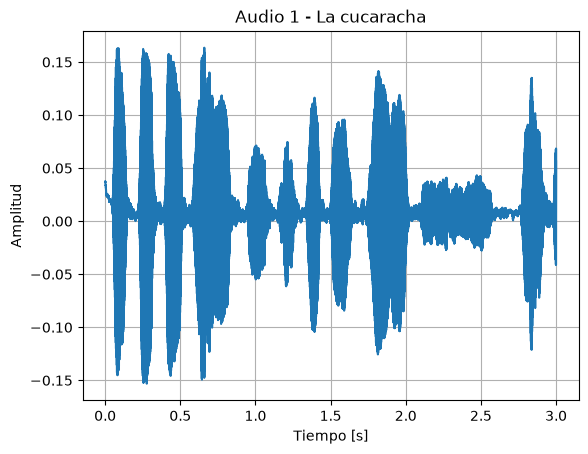

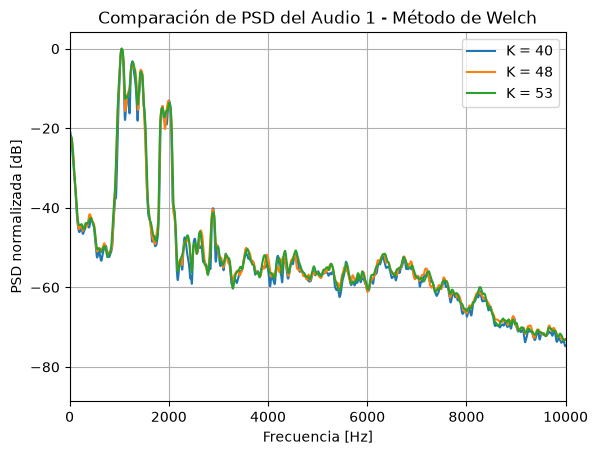

In [13]:
fs_audio1, audio1 = sio.wavfile.read('la cucaracha.wav')
N_audio1 = len(audio1)

# GRAFICO DE LA SEÑAL ORIGINAL
T_audio1 = N_audio1 / fs_audio1
tt_audio1 = np.arange(N_audio1) / fs_audio1

plt.figure()
plt.plot(tt_audio1, audio1)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Audio 1 - La cucaracha')
plt.grid()
plt.show()

# PRUEBO K = 40
K_audio1 = 40
L_audio1 = N_audio1 // K_audio1
ventana = windows.flattop(L_audio1)

f_40_audio1, PSD_welch_40_audio1 = sig.welch(
    audio1,
    fs=fs_audio1,
    window=ventana,
    nperseg=L_audio1,
    noverlap=L_audio1//2,
    nfft=N_audio1
)

PSD_max_40_audio1 = np.max(PSD_welch_40_audio1)
PSD_norm_40_audio1 = PSD_welch_40_audio1 / PSD_max_40_audio1
PSD_db_40_audio1 = 10*np.log10(np.abs(PSD_norm_40_audio1))

#PRUEBO K=48
K_audio1=48
L_audio1=N_audio1//K_audio1
ventana= windows.flattop (L_audio1)

f_48_audio1, PSD_welch_48_audio1= sig.welch (audio1, fs= fs_audio1, window= ventana, nperseg =L_audio1, noverlap= L_audio1//2, nfft=N_audio1)

PSD_welch_max_48_audio1 = np.max(PSD_welch_48_audio1)
PSD_welch_norm_48_audio1 = PSD_welch_48_audio1 / PSD_welch_max_48_audio1
PSD_db_48_audio1 = 10 * np.log10(np.abs(PSD_welch_norm_48_audio1))

#PRUEBO K=53
K_audio1=53
L_audio1=N_audio1//K_audio1
ventana= windows.flattop (L_audio1)

f_53_audio1, PSD_welch_53_audio1= sig.welch (audio1, fs= fs_audio1, window= ventana, nperseg =L_audio1, noverlap= L_audio1//2, nfft=N_audio1)

PSD_welch_max_53_audio1 = np.max(PSD_welch_53_audio1)
PSD_welch_norm_53_audio1 = PSD_welch_53_audio1 / PSD_welch_max_53_audio1
PSD_db_53_audio1 = 10 * np.log10(np.abs(PSD_welch_norm_53_audio1))


#GRAFICO 

plt.figure()

plt.plot(f_40_audio1, PSD_db_40_audio1, color='tab:blue', label='K = 40')
plt.plot(f_48_audio1, PSD_db_48_audio1, color='tab:orange', label='K = 48')
plt.plot(f_53_audio1, PSD_db_53_audio1, color='tab:green', label='K = 53')
plt.xlim(0,10000)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.title('Comparación de PSD del Audio 1 - Método de Welch')
plt.grid()
plt.legend()
plt.show()

En la comparación de las PSD del Audio 1 se observa que las estimaciones obtenidas para $K=40$, $K=48$ y $K=53$ presentan un comportamiento muy similar. Las principales componentes espectrales se concentran aproximadamente entre 1 kHz y 2 kHz, mientras que a frecuencias mayores la potencia disminuye considerablemente.

Las diferencias entre los tres valores de $K$ son pequeñas, por lo que la estimación resulta estable frente a los cambios en la segmentación.

Voy a elegir $K=48$  asi mantengo un compromiso entre resolución espectral y estabilidad de la estimación.

AUDIO 1 - La cucaracha
K=48
Frecuencia inferior: 968.6666666666666 Hz
Frecuencia superior: 2028.3333333333333 Hz
Ancho de banda Audio 1: 1059.6666666666665 Hz


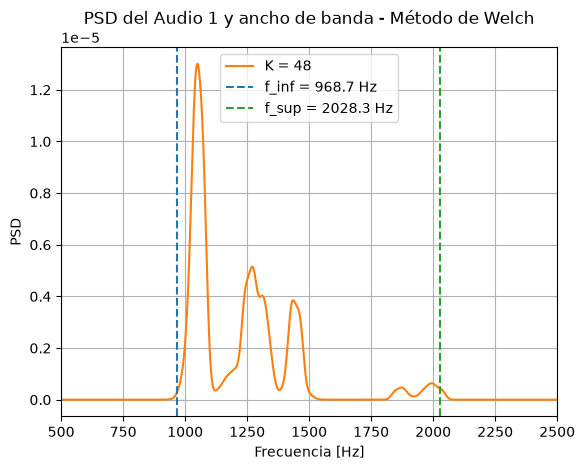

In [15]:
energia_acum = np.cumsum(PSD_welch_48_audio1)
energia_acum = energia_acum / energia_acum[-1]

# limite inferior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.005:
        indice_inf = i
        break

# limite superior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.995:
        indice_sup = i
        break

f_inf_audio1 = f_48_audio1[indice_inf]
f_sup_audio1 = f_48_audio1[indice_sup]

bw_audio1 = f_sup_audio1 - f_inf_audio1

print("AUDIO 1 - La cucaracha")
print ("K=48")
print("Frecuencia inferior:", f_inf_audio1, "Hz")
print("Frecuencia superior:", f_sup_audio1, "Hz")
print("Ancho de banda Audio 1:", bw_audio1, "Hz")

#GRAFICO
plt.figure()

plt.plot(f_48_audio1, PSD_welch_48_audio1,
         color='tab:orange', label='K = 48')

plt.axvline(f_inf_audio1, color='tab:blue', linestyle='--',
            label=f'f_inf = {f_inf_audio1:.1f} Hz')

plt.axvline(f_sup_audio1, color='tab:green', linestyle='--',
            label=f'f_sup = {f_sup_audio1:.1f} Hz')

plt.xlim(500,2500)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del Audio 1 y ancho de banda - Método de Welch')
plt.grid()
plt.legend()
plt.show()

Utilizando $K=48$, se obtuvo una frecuencia inferior de aproximadamente $968,7 Hz$ y una frecuencia superior de $2028,3 Hz$.

A partir de estos límites, el ancho de banda estimado para el Audio 1 fue:

$$
BW_{Audio1}=2028,3-968,7\approx1059,7\text{ Hz}
$$

#### 3'. Audio 2 - Prueba PSD
A continuación se analizó la segunda señal de audio, denominada "Prueba PSD". Al igual que el Audio 1, la señal fue muestreada a 48000 Hz y posee una duración de 3 s.

Para estimar su PSD se utilizó nuevamente el método de Welch, evaluando los valores $K=40$, $K=48$ y $K=53$. Posteriormente, el ancho de banda se determinó utilizando el mismo criterio pasabanda definido anteriormente.

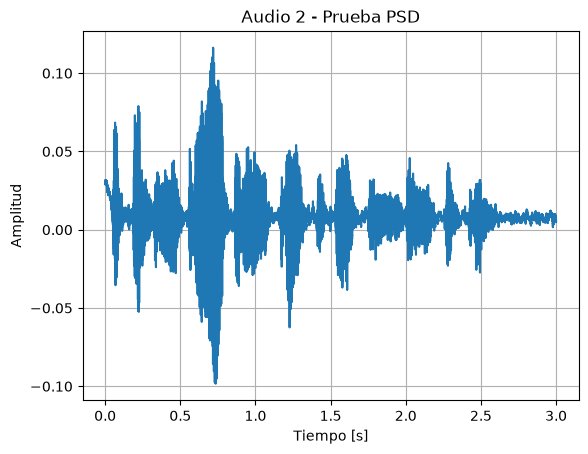

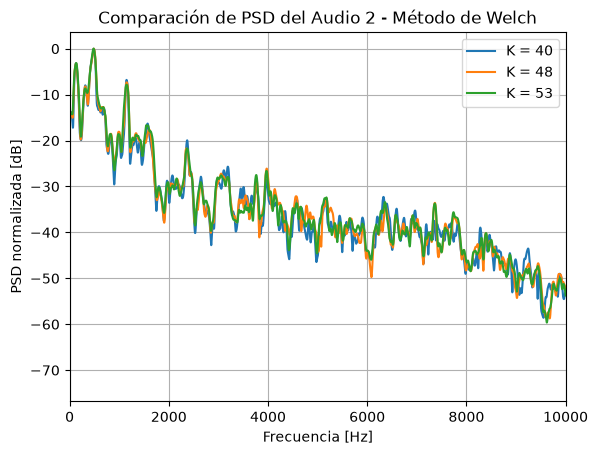

In [18]:
fs_audio2, audio2 = sio.wavfile.read('prueba psd.wav')
N_audio2 = len(audio2)

# GRAFICO DE LA SEÑAL ORIGINAL
T_audio2 = N_audio2 / fs_audio2
tt_audio2 = np.arange(N_audio2) / fs_audio2

plt.figure()
plt.plot(tt_audio2, audio2)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Audio 2 - Prueba PSD')
plt.grid()
plt.show()


### K = 40 ###
K_audio2 = 40
L_audio2 = N_audio2 // K_audio2
ventana = windows.flattop(L_audio2)

f_40_audio2, PSD_welch_40_audio2 = sig.welch(
    audio2,
    fs=fs_audio2,
    window=ventana,
    nperseg=L_audio2,
    noverlap=L_audio2//2,
    nfft=N_audio2
)

PSD_max_40_audio2 = np.max(PSD_welch_40_audio2)
PSD_norm_40_audio2 = PSD_welch_40_audio2 / PSD_max_40_audio2
PSD_db_40_audio2 = 10*np.log10(np.abs(PSD_norm_40_audio2))


### K=48 ###
K_audio2=48
L_audio2=N_audio2//K_audio2
ventana= windows.flattop (L_audio2)

f_48_audio2, PSD_welch_48_audio2= sig.welch(
    audio2,
    fs=fs_audio2,
    window=ventana,
    nperseg=L_audio2,
    noverlap=L_audio2//2,
    nfft=N_audio2
)

PSD_welch_max_48_audio2 = np.max(PSD_welch_48_audio2)
PSD_welch_norm_48_audio2 = PSD_welch_48_audio2 / PSD_welch_max_48_audio2
PSD_db_48_audio2 = 10 * np.log10(np.abs(PSD_welch_norm_48_audio2))


### K=53 ###
K_audio2=53
L_audio2=N_audio2//K_audio2
ventana= windows.flattop (L_audio2)

f_53_audio2, PSD_welch_53_audio2= sig.welch(
    audio2,
    fs=fs_audio2,
    window=ventana,
    nperseg=L_audio2,
    noverlap=L_audio2//2,
    nfft=N_audio2
)

PSD_welch_max_53_audio2 = np.max(PSD_welch_53_audio2)
PSD_welch_norm_53_audio2 = PSD_welch_53_audio2 / PSD_welch_max_53_audio2
PSD_db_53_audio2 = 10 * np.log10(np.abs(PSD_welch_norm_53_audio2))


#GRAFICO

plt.figure()

plt.plot(f_40_audio2, PSD_db_40_audio2, color='tab:blue', label='K = 40')
plt.plot(f_48_audio2, PSD_db_48_audio2, color='tab:orange', label='K = 48')
plt.plot(f_53_audio2, PSD_db_53_audio2, color='tab:green', label='K = 53')

plt.xlim(0,10000)

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.title('Comparación de PSD del Audio 2 - Método de Welch')
plt.grid()
plt.legend()
plt.show()

En la comparación de las PSD del Audio 2 se observa que las estimaciones obtenidas para $K=40$, $K=48$ y $K=53$ presentan un comportamiento muy similar, por lo que nuevamente la estimación espectral no cambia de manera significativa al modificar la segmentación.

A diferencia del Audio 1, el contenido espectral de esta señal se encuentra distribuido en un rango de frecuencias más amplio, presentando componentes importantes tanto en bajas frecuencias como en frecuencias más altas.

Voy a elegir $K=48$  asi mantengo un compromiso entre resolución espectral y estabilidad de la estimación.

AUDIO 2 - Prueba PSD
K=48
Frecuencia inferior: 24.0 Hz
Frecuencia superior: 3954.6666666666665 Hz
Ancho de banda Audio 2: 3930.6666666666665 Hz


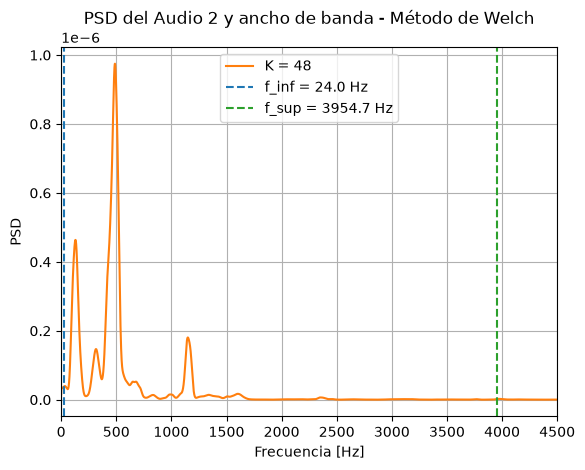

In [20]:
energia_acum = np.cumsum(PSD_welch_48_audio2)
energia_acum = energia_acum / energia_acum[-1]

# limite inferior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.005:
        indice_inf = i
        break

# limite superior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.995:
        indice_sup = i
        break

f_inf_audio2 = f_48_audio2[indice_inf]
f_sup_audio2 = f_48_audio2[indice_sup]

bw_audio2 = f_sup_audio2 - f_inf_audio2

print("AUDIO 2 - Prueba PSD")
print("K=48")
print("Frecuencia inferior:", f_inf_audio2, "Hz")
print("Frecuencia superior:", f_sup_audio2, "Hz")
print("Ancho de banda Audio 2:", bw_audio2, "Hz")


#GRAFICO 
plt.figure()

plt.plot(f_48_audio2, PSD_welch_48_audio2,
         color='tab:orange', label='K = 48')

plt.axvline(f_inf_audio2, color='tab:blue', linestyle='--',
            label=f'f_inf = {f_inf_audio2:.1f} Hz')

plt.axvline(f_sup_audio2, color='tab:green', linestyle='--',
            label=f'f_sup = {f_sup_audio2:.1f} Hz')

plt.xlim(0,4500)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del Audio 2 y ancho de banda - Método de Welch')
plt.grid()
plt.legend()
plt.show()

Utilizando $K=48$, se obtuvo una frecuencia inferior de aproximadamente $24,0 Hz$ y una frecuencia superior de $3954,7 Hz$.

El ancho de banda estimado para el Audio 2 fue:

$$
BW_{Audio2}=3954,7-24,0\approx3930,7\text{ Hz}
$$

En comparación con el Audio 1, esta señal presenta un ancho de banda considerablemente mayor, lo que indica que su potencia espectral se encuentra distribuida en un rango más amplio de frecuencias.

#### 3''. Audio 3 - Silbido
Finalmente, se analizó la tercera señal de audio, correspondiente a un silbido. La señal fue muestreada a 48000 Hz y posee una duración de 3 s.

Para estimar su PSD se utilizó nuevamente el método de Welch, evaluando los valores $K=40$, $K=48$ y $K=53$. El ancho de banda se determinó utilizando el mismo criterio pasabanda empleado para los audios anteriores.

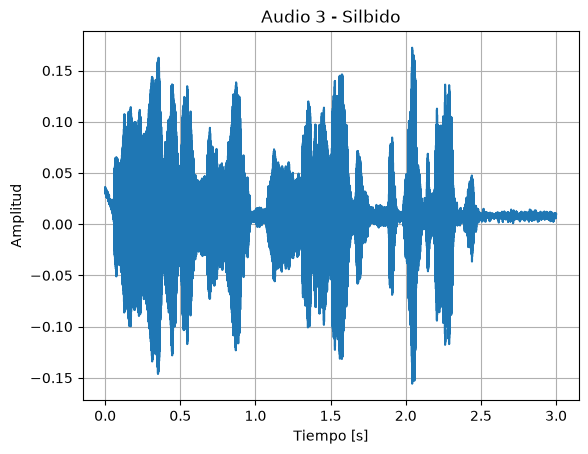

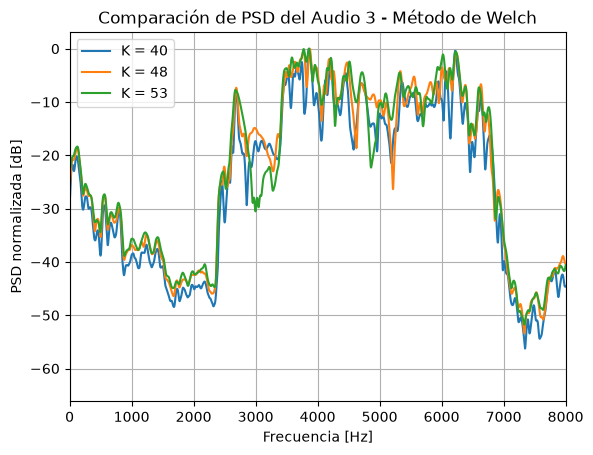

In [22]:
fs_audio3, audio3 = sio.wavfile.read('silbido.wav')
N_audio3 = len(audio3)

# GRAFICO DE LA SEÑAL ORIGINAL
T_audio3 = N_audio3 / fs_audio3
tt_audio3 = np.arange(N_audio3) / fs_audio3

plt.figure()
plt.plot(tt_audio3, audio3)

plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('Audio 3 - Silbido')
plt.grid()
plt.show()

### K = 40 ###
K_audio3 = 40
L_audio3 = N_audio3 // K_audio3
ventana = windows.flattop(L_audio3)

f_40_audio3, PSD_welch_40_audio3 = sig.welch(
    audio3,
    fs=fs_audio3,
    window=ventana,
    nperseg=L_audio3,
    noverlap=L_audio3//2,
    nfft=N_audio3
)

PSD_max_40_audio3 = np.max(PSD_welch_40_audio3)
PSD_norm_40_audio3 = PSD_welch_40_audio3 / PSD_max_40_audio3
PSD_db_40_audio3 = 10*np.log10(np.abs(PSD_norm_40_audio3))


### K=48 ###
K_audio3=48
L_audio3=N_audio3//K_audio3
ventana= windows.flattop (L_audio3)

f_48_audio3, PSD_welch_48_audio3= sig.welch(
    audio3,
    fs=fs_audio3,
    window=ventana,
    nperseg=L_audio3,
    noverlap=L_audio3//2,
    nfft=N_audio3
)

PSD_welch_max_48_audio3 = np.max(PSD_welch_48_audio3)
PSD_welch_norm_48_audio3 = PSD_welch_48_audio3 / PSD_welch_max_48_audio3
PSD_db_48_audio3 = 10 * np.log10(np.abs(PSD_welch_norm_48_audio3))


### K=53 ###
K_audio3=53
L_audio3=N_audio3//K_audio3
ventana= windows.flattop (L_audio3)

f_53_audio3, PSD_welch_53_audio3= sig.welch(
    audio3,
    fs=fs_audio3,
    window=ventana,
    nperseg=L_audio3,
    noverlap=L_audio3//2,
    nfft=N_audio3
)

PSD_welch_max_53_audio3 = np.max(PSD_welch_53_audio3)
PSD_welch_norm_53_audio3 = PSD_welch_53_audio3 / PSD_welch_max_53_audio3
PSD_db_53_audio3 = 10 * np.log10(np.abs(PSD_welch_norm_53_audio3))


#GRAFICO
plt.figure()

plt.plot(f_40_audio3, PSD_db_40_audio3, color='tab:blue', label='K = 40')
plt.plot(f_48_audio3, PSD_db_48_audio3, color='tab:orange', label='K = 48')
plt.plot(f_53_audio3, PSD_db_53_audio3, color='tab:green', label='K = 53')

plt.xlim(0,8000)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.title('Comparación de PSD del Audio 3 - Método de Welch')
plt.grid()
plt.legend()
plt.show()

En la comparación de las PSD del Audio 3 se observa que las estimaciones correspondientes a $K=40$, $K=48$ y $K=53$ mantienen la misma distribución general del contenido espectral.

La mayor parte de la potencia se concentra en una banda de frecuencias más altas que en los audios anteriores, aproximadamente entre 2,5 kHz y 7 kHz, comportamiento esperado para una señal de silbido.

Para $K=40$ se observan mayores variaciones en la estimación, mientras que al aumentar $K$ la PSD resulta más suavizada. Elijo $K=53$, ya que permite obtener una estimación más estable.

AUDIO 3 - Silbido
K=53
Frecuencia inferior: 2621.0 Hz
Frecuencia superior: 6744.333333333333 Hz
Ancho de banda Audio 3: 4123.333333333333 Hz


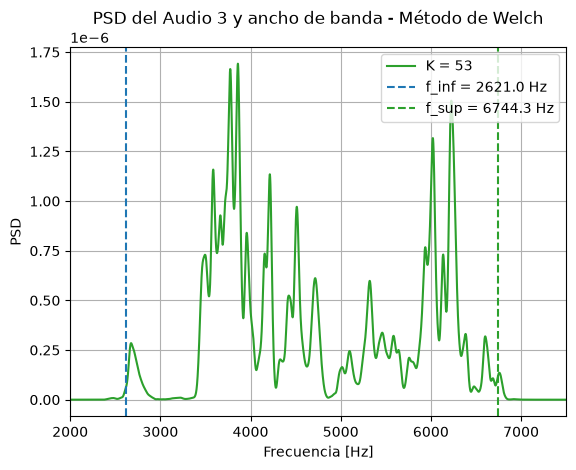

In [23]:
energia_acum = np.cumsum(PSD_welch_53_audio3)
energia_acum = energia_acum / energia_acum[-1]

# limite inferior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.005:
        indice_inf = i
        break

# limite superior
for i in range(len(energia_acum)):
    if energia_acum[i] >= 0.995:
        indice_sup = i
        break

f_inf_audio3 = f_53_audio3[indice_inf]
f_sup_audio3 = f_53_audio3[indice_sup]

bw_audio3 = f_sup_audio3 - f_inf_audio3

print("AUDIO 3 - Silbido")
print("K=53")
print("Frecuencia inferior:", f_inf_audio3, "Hz")
print("Frecuencia superior:", f_sup_audio3, "Hz")
print("Ancho de banda Audio 3:", bw_audio3, "Hz")


#GRAFICO
plt.figure()

plt.plot(f_53_audio3, PSD_welch_53_audio3,
         color='tab:green', label='K = 53')

plt.axvline(f_inf_audio3, color='tab:blue', linestyle='--',
            label=f'f_inf = {f_inf_audio3:.1f} Hz')

plt.axvline(f_sup_audio3, color='tab:green', linestyle='--',
            label=f'f_sup = {f_sup_audio3:.1f} Hz')

plt.xlim(2000,7500)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('PSD del Audio 3 y ancho de banda - Método de Welch')
plt.grid()
plt.legend()
plt.show()

Utilizando $K=53$, se obtuvo una frecuencia inferior de aproximadamente $2621,0 Hz$ y una frecuencia superior de $6744,3 Hz$.

El ancho de banda estimado para el Audio 3 fue:

$$
BW_{Audio3}=6744,3-2621,0\approx4123,3\text{ Hz}
$$

En este caso, la banda de frecuencias se encuentra desplazada hacia valores más altos que en los audios anteriores, lo cual se corresponde con el contenido espectral observado para la señal de silbido.

#### 4. Comparación de resultados

A partir de las estimaciones realizadas, se obtuvieron los siguientes anchos de banda:

| Señal | K seleccionado | Frecuencia inferior [Hz] | Frecuencia superior [Hz] | Ancho de banda [Hz] |
|---|---:|---:|---:|---:|
| ECG | 30 | 0 | 30,6 | 30,6 |
| PPG | 30 | 0 | 5,5 | 5,5 |
| Audio 1 - La cucaracha | 48 | 968,7 | 2028,3 | 1059,7 |
| Audio 2 - Prueba PSD | 48 | 24,0 | 3954,7 | 3930,7 |
| Audio 3 - Silbido | 53 | 2621,0 | 6744,3 | 4123,3 |

En este trabajo pudimos analizar como influye la elección de los parámetros del método de Welch sobre la estimación de la PSD.

Al comparar distintos valores de $K$ logramos visualizar el compromiso entre resolución espectral y estabilidad de la estimación. Cuando se utilizan segmentos más largos se conservan mejor los detalles del espectro, mientras que al usar segmentos más cortos la estimación resulta más suavizada, aunque se pierde resolución.

La estimación del ancho de banda permitió interpretar de una manera más concreta cuánto ocupa cada señal en frecuencia. Comparar esos valores ayudó a ver que no todas las señales necesitan el mismo rango espectral y que el ancho de banda es una forma de resumir dónde se encuentra concentrada la mayor parte de su potencia.

En general, el trabajo me permitió relacionar mejor lo que se observa en los gráficos de PSD con las características reales de cada señal y entender por qué la elección de los parámetros no es arbitraria, sino que depende de qué información se quiere conservar en la estimación.